In [1]:
import warnings
warnings.filterwarnings("ignore")

In [124]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats

import os
print(os.getcwd())
os.chdir('D:\CDAC\AAS\Capstone Project - EDA and Linear Regression')
os.getcwd()

D:\CDAC\AAS\Capstone Project - EDA and Linear Regression


'D:\\CDAC\\AAS\\Capstone Project - EDA and Linear Regression'

In [3]:
files = [
    "loans_master.csv",
    "customer_bureau.csv",
    "loan_performance.csv",
    "payment_history.csv",
    "monthly_emi_track.csv",
    "loan_enquiry_bureau.csv",
    "collateral_assets.csv",
    "credit_card_behavior.csv",
    "branch_region_economy.csv"
]

for file in files:
    print(f"Reading {file}...")
    df = pd.read_csv(file)
    print(f"Shape of {file}: {df.shape}")
    print(f"Columns in {file}: {df.columns.tolist()}")
    print("\n")

Reading loans_master.csv...
Shape of loans_master.csv: (2000000, 27)
Columns in loans_master.csv: ['loan_id', 'issue_date', 'issue_year', 'issue_month', 'loan_amnt_inr', 'funded_amnt_inr', 'loan_term_months', 'int_rate_pct', 'installment_inr', 'annual_installment_inr', 'grade', 'sub_grade', 'loan_purpose', 'state_code', 'region', 'urban_index', 'application_type', 'pymnt_plan', 'hardship_flag', 'initial_list_status', 'disbursement_method', 'verification_status', 'rbi_repo_rate_pct', 'gdp_growth_pct', 'cpi_inflation_pct', 'rate_spread_pct', 'real_interest_rate_pct']


Reading customer_bureau.csv...
Shape of customer_bureau.csv: (2000000, 30)
Columns in customer_bureau.csv: ['loan_id', 'customer_id', 'age', 'gender', 'emp_title', 'emp_length_years', 'home_ownership', 'annual_inc_inr', 'dti_pct', 'cibil_score', 'earliest_cr_line', 'credit_hist_years', 'revol_bal_inr', 'revol_util_pct', 'open_acc', 'total_acc', 'mort_acc', 'pub_rec', 'delinq_2yrs', 'num_inq_last6m', 'num_inq_last12m', 'pct

# Question 1 - DATA ACQUISITION, JOINING & CLEANING

## (a) Load and downcast files individually

In [4]:
exclude_cats = {'loan_id', 'customer_id', 'earliest_cr_line', 'valuation_date', 'last_emi_payment_date', 'loan_approved_date'}

downcast_df = []

for f in files:
    # Read the CSV file into DataFrame
    df = pd.read_csv(f, low_memory=False)

    # Identify columns by data type
    integer_col = df.select_dtypes(include=['int64']).columns
    float_col = df.select_dtypes(include=['float64']).columns
    obj_col = [col for col in df.select_dtypes(include=['object']).columns if col not in exclude_cats]

    # Convert integer columns to int32
    for col in integer_col:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    # Convert float columns to float32
    for col in float_col:
        df[col] = pd.to_numeric(df[col], downcast='float')
    # Convert object columns to category
    for col in obj_col:
        df[col] = df[col].astype('category')

    downcast_df.append(df)

print("\nMerging all files into a single DataFrame...\n")

master_df = downcast_df[0]
for df in downcast_df[1:]:
    master_df = master_df.merge(df, on='loan_id', how='left')
    
# Save the optimized DataFrame into Parquet format
output_file = 'master_dataframe.parquet'
master_df.to_parquet(output_file, index=False)

# Checking memory of parquet file
memory_usage_after = os.path.getsize(output_file) / (1024 * 1024)  # Size in MB's

print(f"Memory usage of the Parquet file: {memory_usage_after:.2f} MB")
print(f"Shape of Master DataFrame: {master_df.shape}")


Merging all files into a single DataFrame...

Memory usage of the Parquet file: 417.81 MB
Shape of Master DataFrame: (2000000, 182)


## (b) The number of orphan records


In [5]:
df = pd.read_parquet('master_dataframe.parquet')

print(f"Orphans in the Master DataFrame: {df['loan_id'].isnull().sum()}")
print(f"Final Data Shape: {df.shape}")


Orphans in the Master DataFrame: 0
Final Data Shape: (2000000, 182)


## (c) Clean 8 Deliberate Data Quality Issues

In [6]:
df['dirty_flag'] = 0

issues = {}

# NPA Status Mismatch
npa_fault = (df['loan_status'] == 1) & (df['npa_flag'] == 0)
issues['npa_status_mismatch'] = int(npa_fault.sum())
df.loc[npa_fault, 'dirty_flag'] = 1
df.loc[df['loan_status'] == 1, 'npa_flag'] = 1


In [7]:
# Zero Collateral Value for Secured Loans
zero_collateral_fault = (df['has_collateral'] == 1) & (df['collateral_value_inr'] == 0)
issues['zero_collateral_value'] = int(zero_collateral_fault.sum())
df.loc[zero_collateral_fault, 'dirty_flag'] = 1

# Optimized indexing
secured_median = df.loc[(df['has_collateral'] == 1) & (df['collateral_value_inr'] > 0), 'collateral_value_inr'].median()
df.loc[zero_collateral_fault, 'collateral_value_inr'] = np.float32(secured_median)

In [8]:
# Invalid Rejection Rate
reject_rate = df['rejection_rate_pct'] > 100
issues['invalid_rejection_rate'] = int(reject_rate.sum())
df.loc[reject_rate, 'rejection_rate_pct'] = 100

In [9]:
# Credit History and Age Inconsistencies
age_issue = df['credit_hist_years'] > df['age']
issues['age_credit_hist_inconsistency'] = int(age_issue.sum())
df.loc[age_issue, 'dirty_flag'] = 1
df.loc[age_issue, 'credit_hist_years'] = np.maximum(0, df.loc[age_issue, 'age'] - 18).astype(df['credit_hist_years'].dtype)

In [10]:
issues

{'npa_status_mismatch': 77541,
 'zero_collateral_value': 120084,
 'invalid_rejection_rate': 3168,
 'age_credit_hist_inconsistency': 132333}

## (d) Classify and Impute High-Missing Columns

In [ ]:
cols = ['mths_since_last_delinq', 'mort_acc', 'emp_length_years', 'il_util_pct']

# Track missing counts before
missing_before = df[cols].isna().sum().to_dict()

# Create missing indicator for mths_since_last_delinq
df['mths_since_last_delinq_missing'] = df['mths_since_last_delinq'].isnull().astype(int)

# Impute values for MAR columns with median, and MNAR column with -1
impute_values = {
    c: df[c].median() for c in cols if c != 'mths_since_last_delinq'
}
impute_values['mths_since_last_delinq'] = -1

# Apply all imputation 
df = df.fillna(impute_values)
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].astype('float32')

# Missing After imputation
missing_after = df[cols].isna().sum().to_dict()

print("Missing Values Before Imputation:")
for col, count in missing_before.items():
    print(f"{col}: {count}")
print("\nMissing Values After Imputation:")
for col, count in missing_after.items():
    print(f"{col}: {count}")


Missing Values Before Imputation:
mths_since_last_delinq: 1098640
mort_acc: 260330
emp_length_years: 180539
il_util_pct: 200167

Missing Values After Imputation:
mths_since_last_delinq: 0
mort_acc: 0
emp_length_years: 0
il_util_pct: 0


## (e) Winsorisation of 6 most skewed numeric columns

In [26]:
from itertools import islice

all_nums = df.select_dtypes(include=[np.number]).columns
skew_vals = {}
for col in all_nums:
    skew_vals[col] = abs(float(df[col].skew()))

skew_vals = dict(islice(sorted(skew_vals.items(), key=lambda x: x[1], reverse=True), 6))
skew_vals

{'collections_12mths_fee': 139.0354117763462,
 'collection_recovery_fee': 125.76596285409279,
 'recoveries_inr': 94.23248025277961,
 'emi_advance_paid_inr': 59.17167262332933,
 'expected_loss_inr': 27.014741286752695,
 'avg_cur_bal_inr': 25.655978911987326}

In [37]:
# Winsorization for top 6 skewed columns
winsorise_stats = {}

quantiles = df[skew_vals.keys()].quantile([0.01, 0.99])

for col in skew_vals.keys():
    before = df[col].describe().to_dict()

    p_01, p_99 = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p_01, upper=p_99)

    after = df[col].describe().to_dict()
    winsorise_stats[col] = {
        'before': before,
        'after': after,
        'p_01': float(p_01),
        'p_99': float(p_99)
    }

for i in winsorise_stats:
    print(f"\nColumn: {i}")
    print(f"Before Winsorization: {winsorise_stats[i]['before']}")
    print(f"After Winsorization: {winsorise_stats[i]['after']}")
    print(f"1st Percentile (p_01): {winsorise_stats[i]['p_01']}")
    print(f"99th Percentile (p_99): {winsorise_stats[i]['p_99']}")



Column: collections_12mths_fee
Before Winsorization: {'count': 2000000.0, 'mean': 11.829475100002, 'std': 77.2961113802627, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 657.2200000002}
After Winsorization: {'count': 2000000.0, 'mean': 11.82947510000002, 'std': 77.2961113802462, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 657.2200000000021}
1st Percentile (p_01): 0.0
99th Percentile (p_99): 657.2200000000021

Column: collection_recovery_fee
Before Winsorization: {'count': 1879914.0, 'mean': 55.189011866508196, 'std': 348.5224728068943, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 2910.9974954263234}
After Winsorization: {'count': 1879914.0, 'mean': 55.18883311427684, 'std': 348.5210081039233, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 2910.9796210208847}
1st Percentile (p_01): 0.0
99th Percentile (p_99): 2910.9796210208847

Column: recoveries_inr
Before Winsorization: {'count': 2000000.0, 'mean': 22.139089064999997, 'std': 140.0217871099319, '

# Question 2 - EXPLORATORY DATA ANALYSIS

## (a) Loan Status Distribution

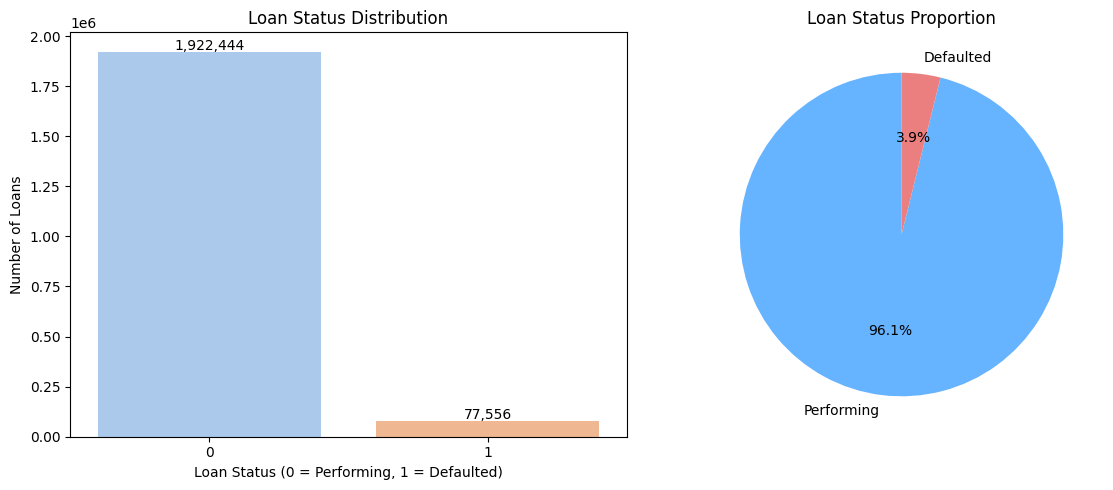

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar Plot
status_records = df['loan_status'].value_counts()
sns.barplot(x=status_records.index, y=status_records.values, ax=ax[0], hue=status_records.index, legend=False, palette='pastel')
ax[0].set_title('Loan Status Distribution')
ax[0].set_xlabel('Loan Status (0 = Performing, 1 = Defaulted)')
ax[0].set_ylabel('Number of Loans')
for i, val in enumerate(status_records.values):
    ax[0].text(i, val + 10000, f"{val:,}", ha='center')


# Pie Chart
ax[1].pie(status_records.values, labels=["Performing", "Defaulted"], autopct='%1.1f%%', startangle=90, colors=['#66b3ff', "#eb7f7f"])
ax[1].set_title('Loan Status Proportion')
plt.tight_layout()
plt.show()

## (b) KDE Curve for cibil_score

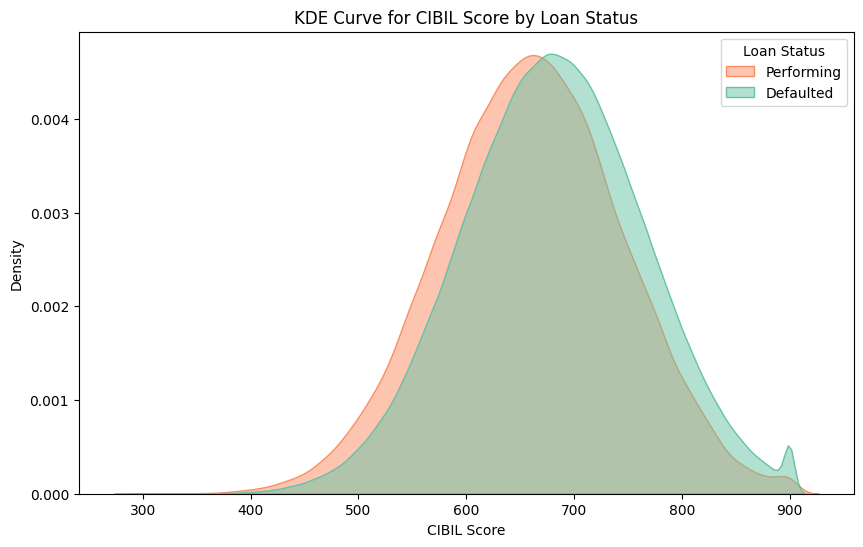

In [64]:
plt.figure(figsize = (10, 6))
sns.kdeplot(df, x="cibil_score", hue='loan_status', fill=True, palette='Set2', alpha=0.5,common_norm=False)
plt.title("KDE Curve for CIBIL Score by Loan Status")
plt.xlabel("CIBIL Score")
plt.ylabel("Density")
plt.legend(title='Loan Status', labels=['Performing', 'Defaulted'])
plt.show()

### (c) 12-Panel Histogram Grid of Key Numeric Features


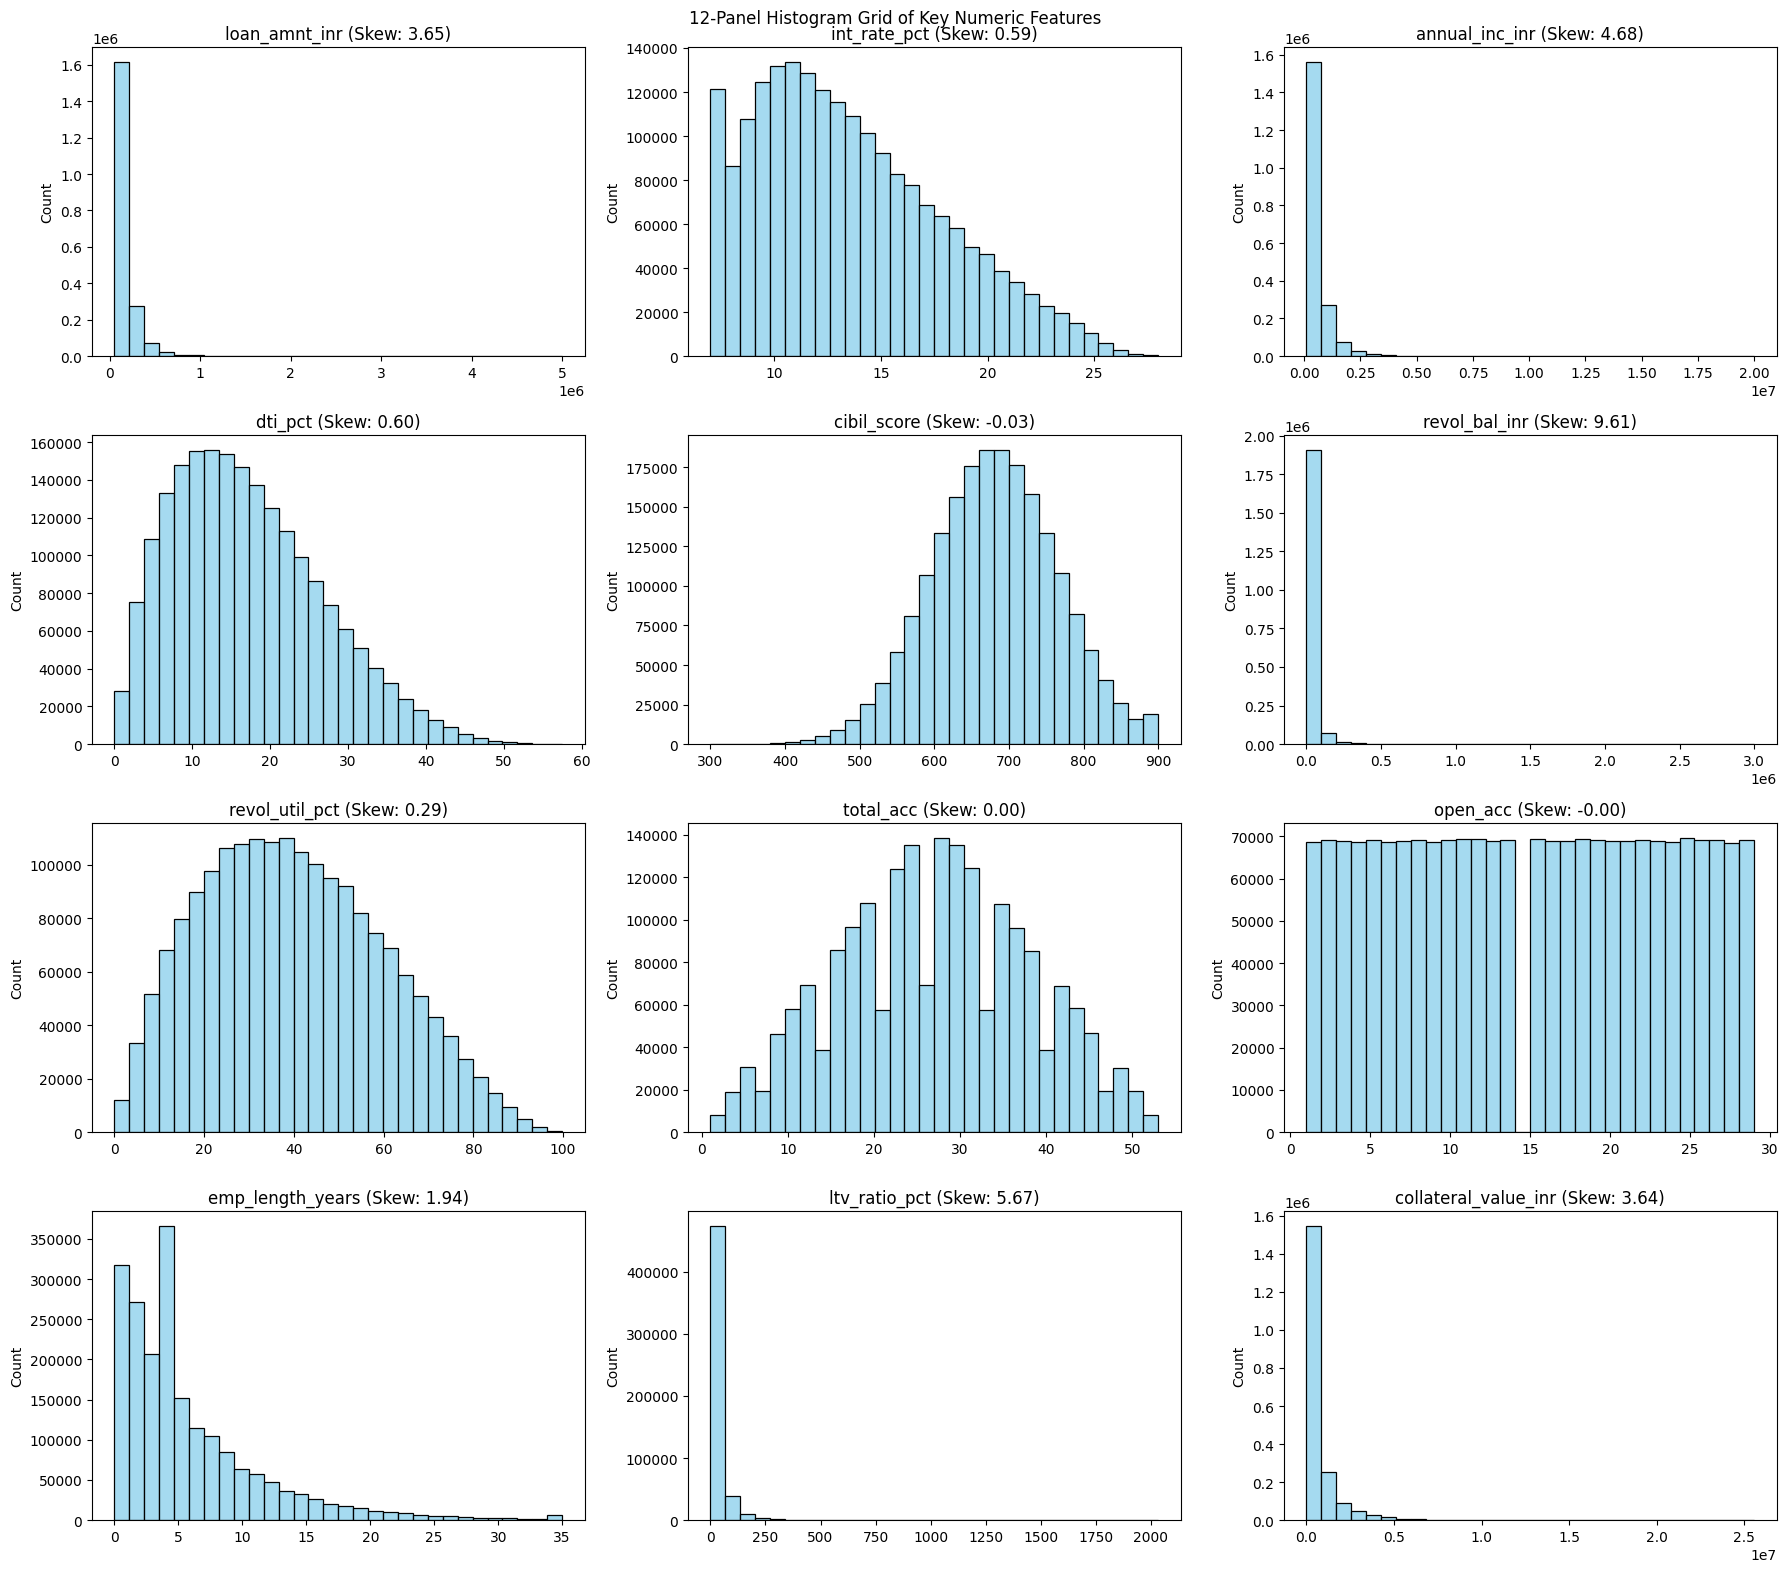

In [76]:
features_to_plot = [
    'loan_amnt_inr', 'int_rate_pct', 'annual_inc_inr', 'dti_pct', 
    'cibil_score', 'revol_bal_inr', 'revol_util_pct', 'total_acc', 
    'open_acc', 'emp_length_years', 'ltv_ratio_pct', 'collateral_value_inr'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(df[col], bins=30, kde=False, color='skyblue', ax=axes[i])
    skew_vals = df[col].skew()
    axes[i].set_title(f"{col} (Skew: {skew_vals:.2f})")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

plt.suptitle("12-Panel Histogram Grid of Key Numeric Features")
plt.tight_layout()
plt.show()


### (d) Pearson Correlation Matrix Heatmap


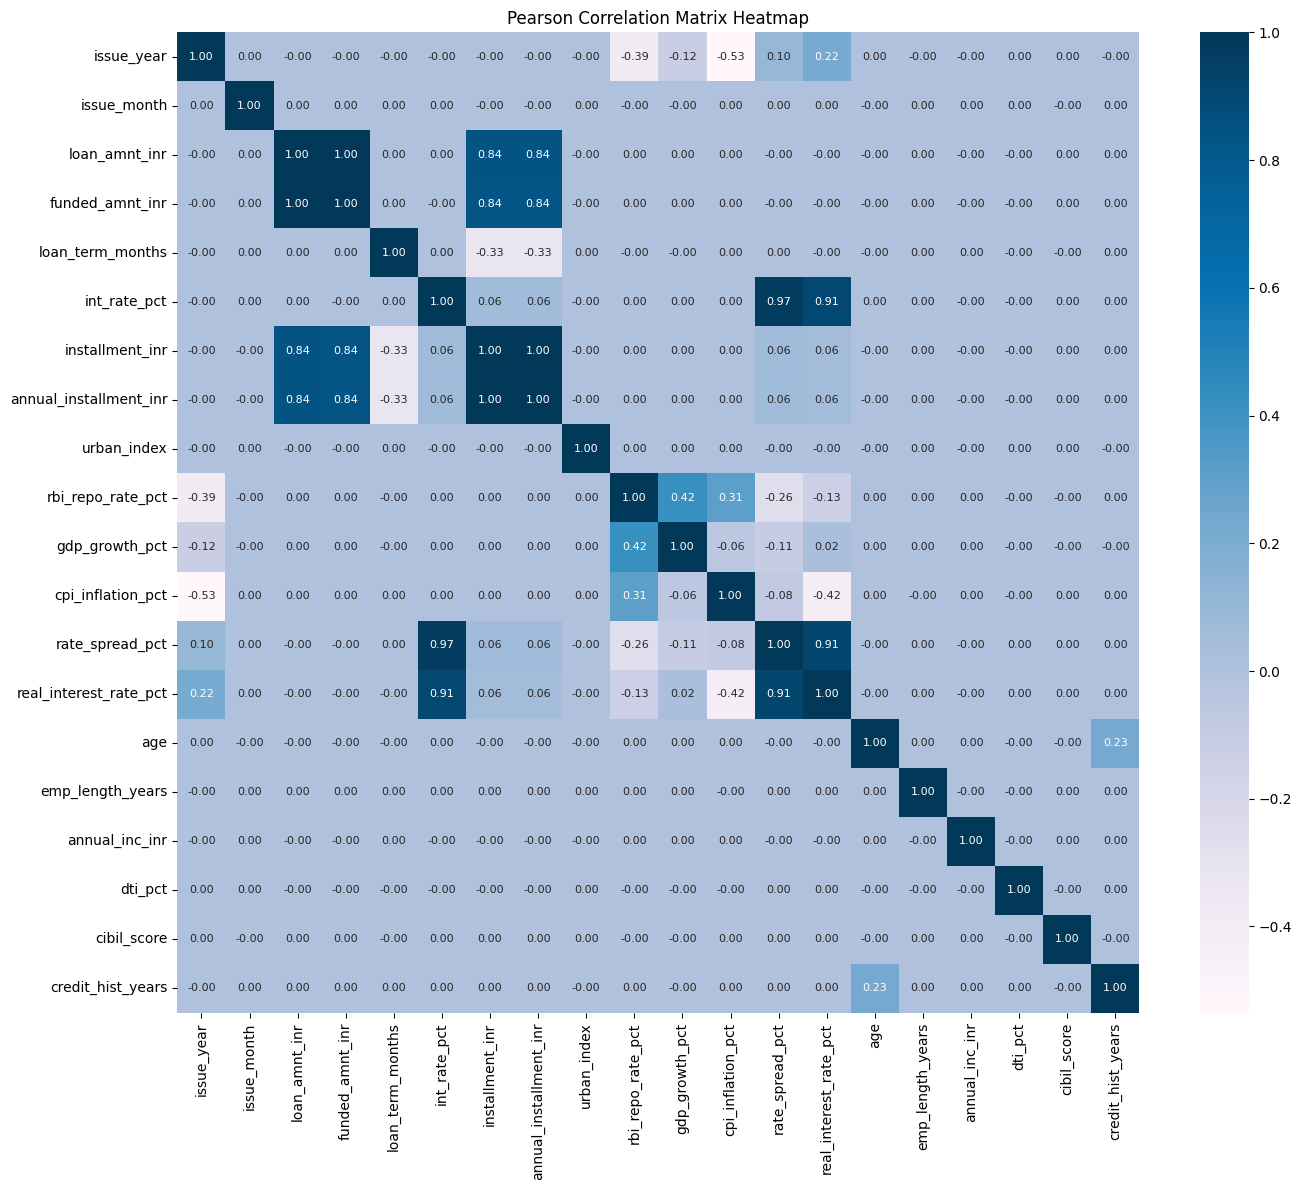

In [81]:
numeric_col = df.select_dtypes(include=[np.number]).columns
exclude_col = ['loan_status', 'dirty_flag', 'covid_issue_year_flag', 'mths_since_last_delinq_missing']
cat_col = [c for c in numeric_col if c not in exclude_col]

cor_matrix = df[cat_col[:20]].corr()

plt.figure(figsize=(14,12))
sns.heatmap(cor_matrix, annot=True, fmt='.2f', cmap='PuBu', cbar=True, annot_kws={"size": 8})
plt.title("Pearson Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

### (e) Boxplots of Key Features by Loan Status


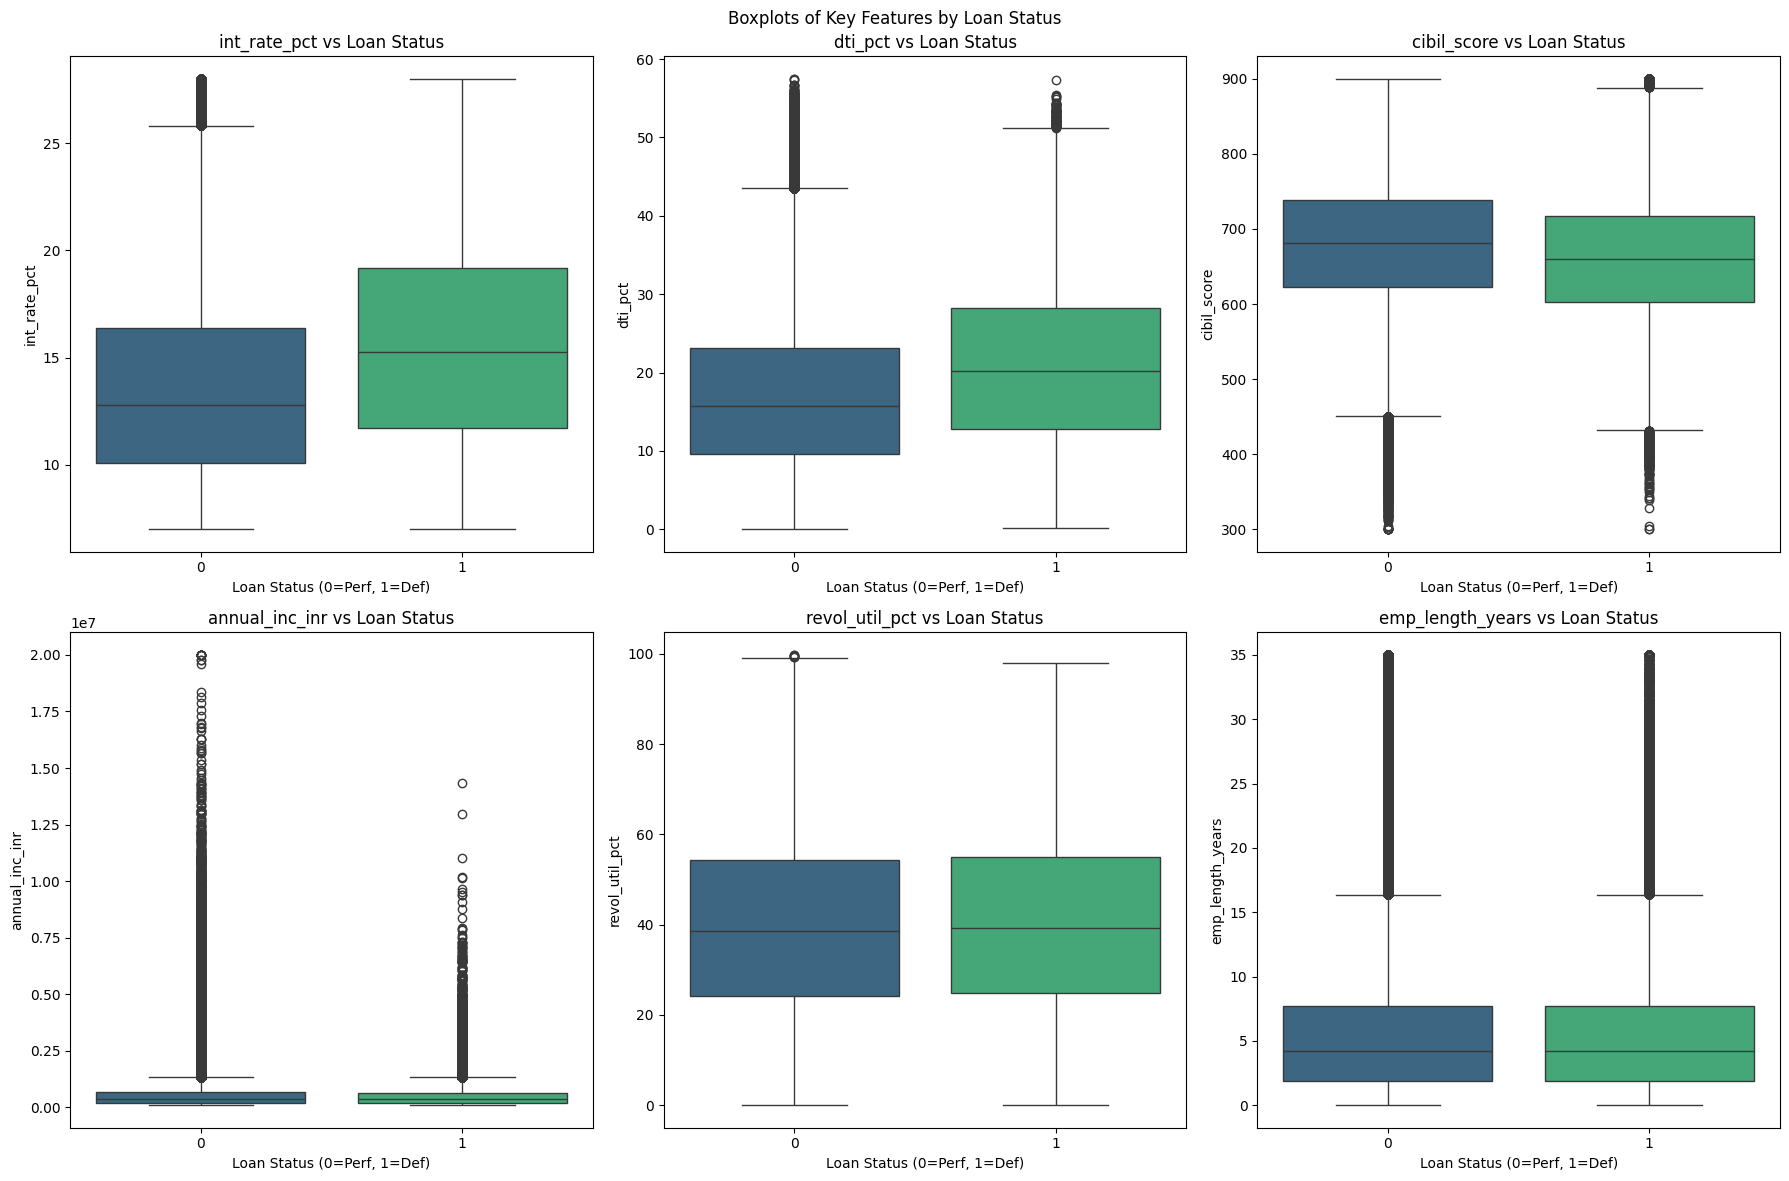

In [90]:
box_features = ['int_rate_pct', 'dti_pct', 'cibil_score', 'annual_inc_inr', 'revol_util_pct', 'emp_length_years']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(box_features):
    sns.boxplot(data=df, x='loan_status', y=col, ax=axes[i], palette='viridis', hue='loan_status', legend=False)

    axes[i].set_title(f"{col} vs Loan Status")
    axes[i].set_xlabel("Loan Status (0=Perf, 1=Def)")
    axes[i].set_ylabel(col)

plt.suptitle("Boxplots of Key Features by Loan Status")
plt.tight_layout()
plt.show()

### (f) Default Rate by Loan Grade

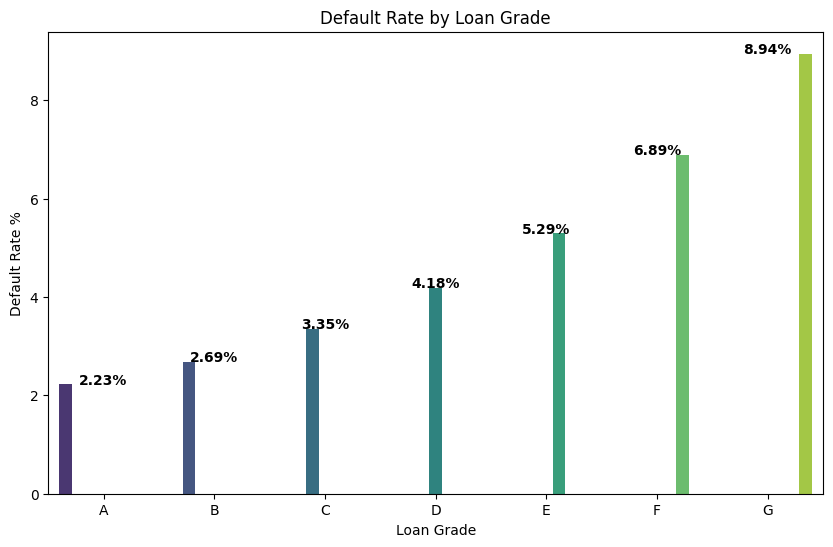

In [101]:
grade_counts = df.groupby('grade', observed=True)['loan_status'].agg(['count', 'sum']) 
grade_counts['default_rate'] = (grade_counts['sum'] / grade_counts['count']) * 100 

plt.figure(figsize=(10, 6)) 
sns.barplot(x=grade_counts.index, y=grade_counts['default_rate'], hue=grade_counts.index, legend=False, palette="viridis") 
plt.title("Default Rate by Loan Grade") 
plt.xlabel("Loan Grade") 
plt.ylabel("Default Rate %") 

for i, rate in enumerate(grade_counts['default_rate']): 
    plt.text(i, rate, f"{rate:.2f}%", ha='center', fontweight='bold') 
plt.show()

### (g) Default Rate by Loan Purpose

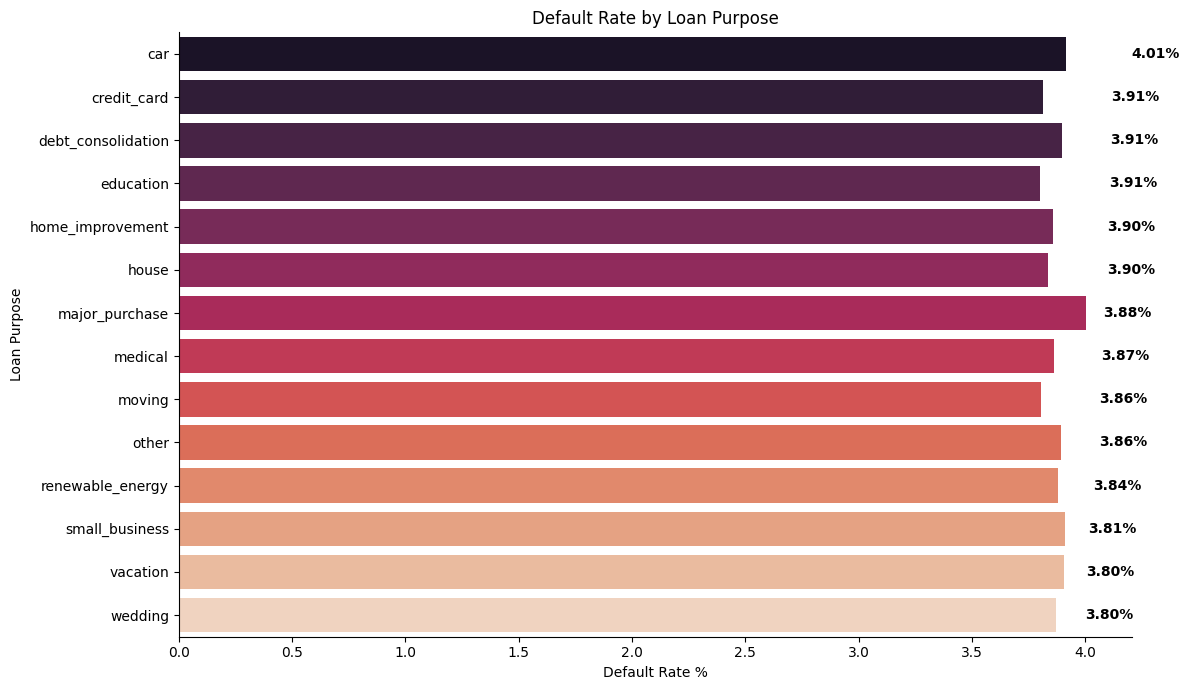

In [ ]:
# 1. Calculate and sort rates
purpose_stats = df.groupby('loan_purpose', observed=True)['loan_status'].agg(['count', 'sum'])
purpose_stats['default_rate'] = (purpose_stats['sum'] / purpose_stats['count']) * 100
purpose_stats = purpose_stats.sort_values(by='default_rate', ascending=False)

# 2. Plot horizontal bars
plt.figure(figsize=(12, 7))
sns.barplot(
    data=purpose_stats, 
    x='default_rate', 
    y=purpose_stats.index,  # Keeps bars in sorted order
    palette="rocket"
)
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate %")
plt.ylabel("Loan Purpose")

# 3. Add text labels to bars safely
for i, rate in enumerate(purpose_stats['default_rate']):
    plt.text(rate + 0.2, i, f"{rate:.2f}%", va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

### (h) Top 10 States with Highest Default Rates

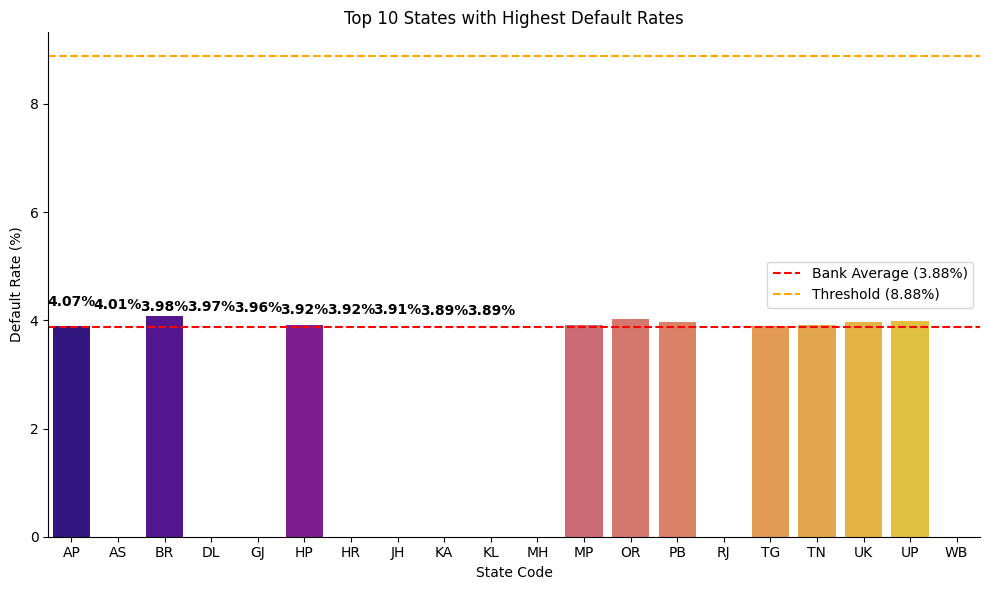

States exceeding the limit: []


In [106]:
# 1. Calculate the overall bank average first to avoid errors
bank_avg = (df['loan_status'].sum() / df['loan_status'].count()) * 100

# 2. Calculate state-level statistics
state_stats = df.groupby('state_code', observed=True)['loan_status'].agg(['count', 'sum'])
state_stats['default_rate'] = (state_stats['sum'] / state_stats['count']) * 100
top_10_states = state_stats.sort_values(by='default_rate', ascending=False).head(10)

# 3. Plot the chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_states.index, y=top_10_states['default_rate'], palette="plasma")

# Add benchmark lines using the calculated bank average
plt.axhline(bank_avg, color='red', linestyle='--', label=f'Bank Average ({bank_avg:.2f}%)')
plt.axhline(bank_avg + 5, color='orange', linestyle='--', label=f'Threshold ({bank_avg+5:.2f}%)')

plt.title("Top 10 States with Highest Default Rates")
plt.xlabel("State Code")
plt.ylabel("Default Rate (%)")
plt.legend()

# 4. Safely add text labels
for i, rate in enumerate(top_10_states['default_rate']):
    plt.text(i, rate + 0.2, f"{rate:.2f}%", ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# 5. Filter and print high risk states
high_risk_states = state_stats[state_stats['default_rate'] > bank_avg + 5]
print(f"States exceeding the limit: {list(high_risk_states.index)}")


### (i) Annual Default Rate Trend (2010 - 2024)

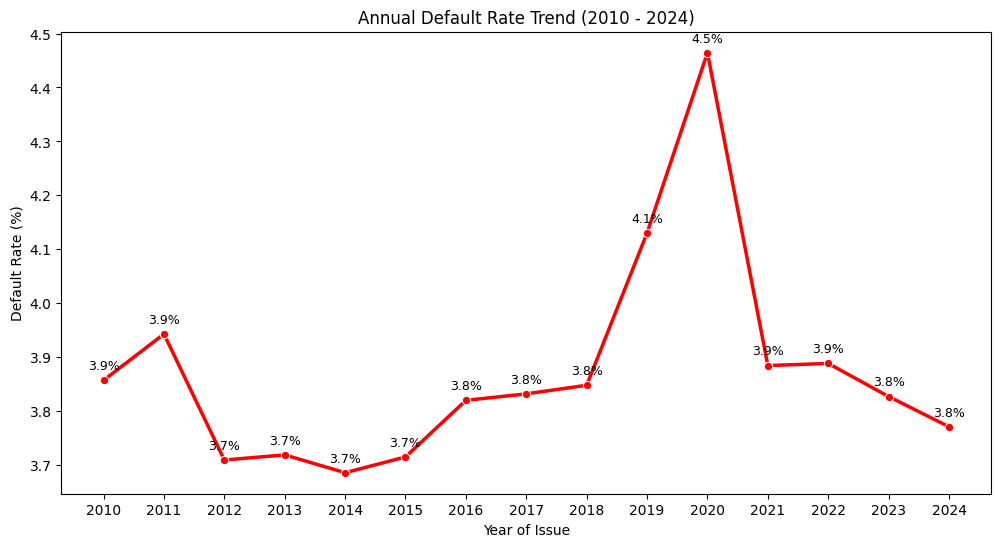

In [115]:
annual_stats = df.groupby('issue_year', observed=True)['loan_status'].agg(['count', 'sum'])
annual_stats['default_rate'] = (annual_stats['sum'] / annual_stats['count']) * 100

plt.figure(figsize=(12, 6))
sns.lineplot(data=annual_stats, x=annual_stats.index, y='default_rate', marker='o', color='red', linewidth=2.5)
plt.title("Annual Default Rate Trend (2010 - 2024)")
plt.xlabel("Year of Issue")
plt.ylabel("Default Rate (%)")
plt.xticks(annual_stats.index)

# Annotate values
for x, y in zip(annual_stats.index, annual_stats['default_rate']):
    plt.text(x, y+0.02, f"{y:.1f}%", ha='center', fontsize=9)

plt.show()

### (j) RBI Repo Rate vs. Annual Default Rate

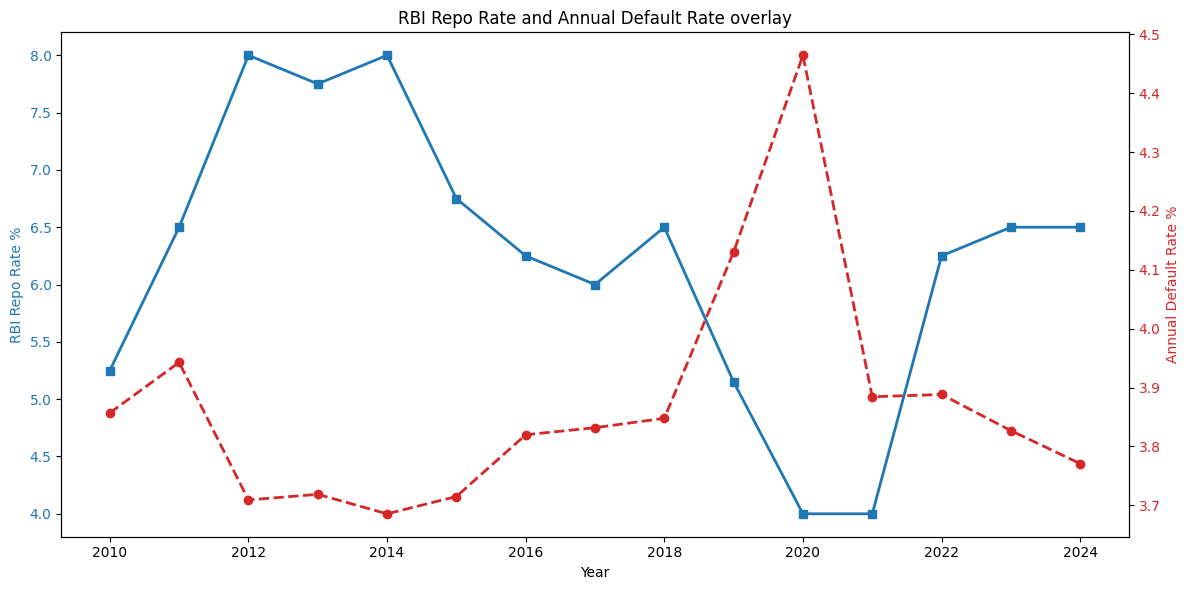

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

annual_repo = df.groupby('issue_year', observed=True)['rbi_repo_rate_pct'].mean()

color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('RBI Repo Rate %', color=color)
ax1.plot(annual_repo.index, annual_repo.values, color=color, marker='s', linewidth=2, label='RBI Repo Rate')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Annual Default Rate %', color=color)
ax2.plot(annual_stats.index, annual_stats['default_rate'], color=color, marker='o', linewidth=2, linestyle='--', label='Default Rate')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("RBI Repo Rate and Annual Default Rate overlay")
fig.tight_layout()  
plt.show()


### (k) LGD Distribution (Defaulted Loans Only)

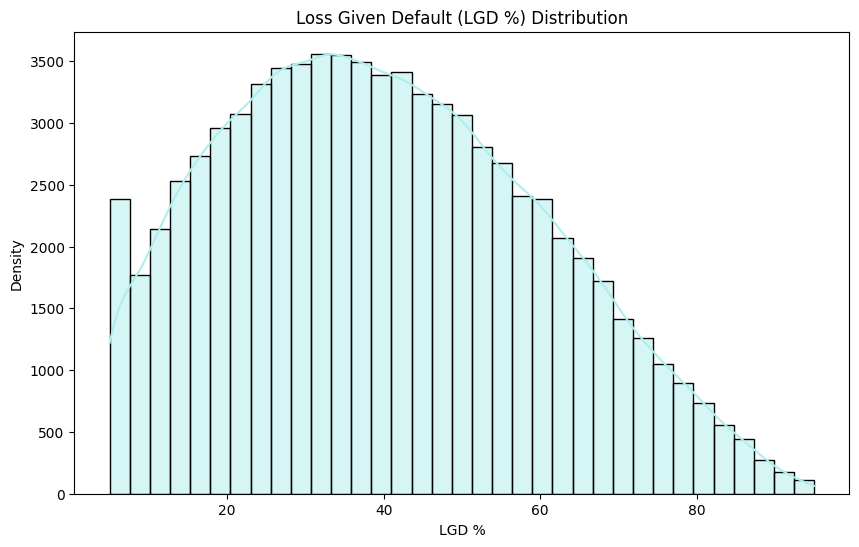

In [ ]:
df_defaulted = df.loc[df['loan_status'] == 1, ['lgd_pct', 'cibil_score']].copy()

plt.figure(figsize=(10, 6))
sns.histplot(df_defaulted['lgd_pct'], bins=35, kde=True, color="paleturquoise")
plt.title("Loss Given Default (LGD %) Distribution")
plt.xlabel("LGD %")
plt.ylabel("Density")
plt.show()

### (l) CIBIL Score vs. LGD Scatter Plot

Pearson Correlation r: 0.0018 (p-value: 6.2277e-01)


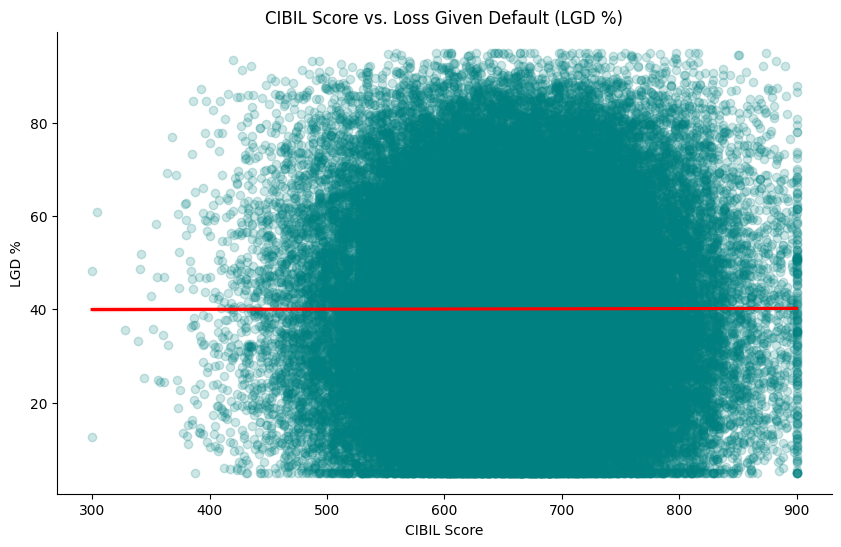

In [127]:
defsample = df[df['loan_status'] == 1]

plt.figure(figsize=(10, 6))
sns.regplot(
    data=defsample, 
    x="cibil_score", 
    y="lgd_pct", 
    scatter_kws={'alpha':0.2, 'color':'teal'}, 
    line_kws={'color':'red'}
)
plt.title("CIBIL Score vs. Loss Given Default (LGD %)")
plt.xlabel("CIBIL Score")
plt.ylabel("LGD %")

r_val, p_val = stats.pearsonr(defsample['cibil_score'], defsample['lgd_pct'])

print(f"Pearson Correlation r: {r_val:.4f} (p-value: {p_val:.4e})")
sns.despine()
plt.show()

# QUESTION 3: FEATURE ENGINEERING

### a. Repayment-Burden Features

In [129]:
# Feature 1 — EMI to Income Ratio
df["emi_to_income_ratio"] = df["installment_inr"] / (df["annual_inc_inr"] / 12)

# Feature 2 — Loan to Income Ratio
df["loan_to_income_ratio"] = df["loan_amnt_inr"] / df["annual_inc_inr"]

# Feature 3 — Rate Spread
df["rate_spread_pct"] = df["int_rate_pct"] - df["rbi_repo_rate_pct"]

# Feature 4 — Real Interest Rate
df["real_interest_rate"] = df["int_rate_pct"] - df["cpi_inflation_pct"]

# Describe all 4
features = ["emi_to_income_ratio", "loan_to_income_ratio",
            "rate_spread_pct", "real_interest_rate"]

for f in features:
    print(f"\n{f}:")
    print(df[f].describe().round(4))

# Correlation with lgd_pct
print("\nCorrelation with lgd_pct:")
print("="*40)
for f in features:
    corr = df[f].corr(df["lgd_pct"])
    print(f"{f:<25}: {corr:.4f}")



emi_to_income_ratio:
count    1.959934e+06
mean     2.147000e-01
std      3.304000e-01
min      5.000000e-04
25%      5.220000e-02
50%      1.140000e-01
75%      2.458000e-01
max      2.858450e+01
Name: emi_to_income_ratio, dtype: float64

loan_to_income_ratio:
count    1.959934e+06
mean     5.516000e-01
std      7.463000e-01
min      2.500000e-03
25%      1.479000e-01
50%      3.134000e-01
75%      6.515000e-01
max      3.385820e+01
Name: loan_to_income_ratio, dtype: float64

rate_spread_pct:
count    2.000000e+06
mean     7.424300e+00
std      4.526900e+00
min     -1.000000e+00
25%      3.920000e+00
50%      6.770000e+00
75%      1.042000e+01
max      2.400000e+01
Name: rate_spread_pct, dtype: float64

real_interest_rate:
count    2.000000e+06
mean     7.639800e+00
std      4.813200e+00
min     -3.900000e+00
25%      4.150000e+00
50%      7.110000e+00
75%      1.081000e+01
max      2.460000e+01
Name: real_interest_rate, dtype: float64

Correlation with lgd_pct:
emi_to_income_ratio  

### b. Bureau-Behaviour Features

In [130]:
# Feature 5 — Credit Utilisation Composite
df["credit_util_composite"] = (0.5 * df["revol_util_pct"] + 
                                0.3 * df["bc_util_pct"] + 
                                0.2 * df["all_util_pct"])

# Feature 6 — Delinquency Severity Score
df["delinq_severity_score"] = df["delinq_2yrs"] * (1 + 1 / 
                               df["mths_since_last_delinq"].clip(lower=1))

# Feature 7 — Enquiry Velocity Score
df["enq_velocity_score"] = (df["num_enquiries_30d"] * 4 + 
                             df["num_enquiries_90d"])

features_b = ["credit_util_composite", 
              "delinq_severity_score",
              "enq_velocity_score"]

for f in features_b:
    print(f"\n{f}:")
    print(df[f].describe().round(4))

print("\nCorrelation with lgd_pct:")
print("="*40)
for f in features_b:
    corr = df[f].corr(df["lgd_pct"])
    print(f"{f:<25}: {corr:.4f}")


credit_util_composite:
count    1.642578e+06
mean     4.057230e+01
std      1.218460e+01
min      3.800000e+00
25%      3.170000e+01
50%      4.006000e+01
75%      4.896000e+01
max      9.082000e+01
Name: credit_util_composite, dtype: float64

delinq_severity_score:
count    1.899793e+06
mean     1.163900e+00
std      1.771400e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.087000e+00
max      1.400000e+01
Name: delinq_severity_score, dtype: float64

enq_velocity_score:
count    2.000000e+06
mean     8.246200e+00
std      7.912300e+00
min      0.000000e+00
25%      2.000000e+00
50%      6.000000e+00
75%      1.200000e+01
max      3.900000e+01
Name: enq_velocity_score, dtype: float64

Correlation with lgd_pct:
credit_util_composite    : 0.0040
delinq_severity_score    : 0.0180
enq_velocity_score       : 0.0005


### c. Income and Collateral Features

In [131]:
# Feature 8 — Income Stability Ratio
df["income_stability_ratio"] = df["annual_inc_inr"] / (df["emp_length_years"] + 1)

# Feature 9 — Credit Depth Score
df["credit_depth_score"] = df["total_acc"] / (df["credit_hist_years"] + 1)

# Feature 10 — Collateral Coverage Ratio
df["collateral_coverage_ratio"] = df["collateral_value_inr"] / (df["loan_amnt_inr"] + 1)

features_c = ["income_stability_ratio",
              "credit_depth_score",
              "collateral_coverage_ratio"]

for f in features_c:
    print(f"\n{f}:")
    print(df[f].describe().round(4))

print("\nCorrelation with lgd_pct:")
print("="*40)
for f in features_c:
    corr = df[f].corr(df["lgd_pct"])
    print(f"{f:<25}: {corr:.4f}")


income_stability_ratio:
count    1.959934e+06
mean     1.439370e+05
std      2.357072e+05
min      2.777778e+03
25%      3.263423e+04
50%      7.181423e+04
75%      1.603416e+05
max      1.818182e+07
Name: income_stability_ratio, dtype: float64

credit_depth_score:
count    2.000000e+06
mean     2.291300e+00
std      2.104700e+00
min      2.860000e-02
25%      9.749000e-01
50%      1.565400e+00
75%      2.802900e+00
max      1.766670e+01
Name: credit_depth_score, dtype: float64

collateral_coverage_ratio:
count    2.000000e+06
mean     5.370000e+00
std      1.330470e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.528200e+00
max      4.562713e+02
Name: collateral_coverage_ratio, dtype: float64

Correlation with lgd_pct:
income_stability_ratio   : -0.0032
credit_depth_score       : 0.0003
collateral_coverage_ratio: 0.0003


### d. Skew Reduction Transformations

In [135]:
# Feature 11 - log_annual_inc
df['log_annual_inc'] = np.log1p(df['annual_inc_inr'])

# Feature 12 - log_loan_amnt
df['log_loan_amnt'] = np.log1p(df['loan_amnt_inr'])

feature_list = ['log_annual_inc','log_loan_amnt']

for f in feature_list:
    print(f'{f}')
    print(df[f].describe().round(4))


print("\nCorrelation with lgd_pct:")
for f in feature_list:
    corr = df[f].corr(df["lgd_pct"])
    print(f"{f:<25}: {corr:.4f}")

log_annual_inc
count    1.959934e+06
mean     1.283090e+01
std      8.415000e-01
min      1.151290e+01
25%      1.219260e+01
50%      1.280020e+01
75%      1.340710e+01
max      1.681120e+01
Name: log_annual_inc, dtype: float64
log_loan_amnt
count    2.000000e+06
mean     1.166550e+01
std      6.759000e-01
min      1.081980e+01
25%      1.107510e+01
50%      1.160070e+01
75%      1.212630e+01
max      1.542490e+01
Name: log_loan_amnt, dtype: float64

Correlation with lgd_pct:
log_annual_inc           : -0.0040
log_loan_amnt            : 0.0009


In [137]:
# Feature 13 - COVID flag
df["covid_issue_year_flag"] = (df["issue_year"] == 2020).astype(int)

# Mean LGD for covid vs non covid
print("Mean LGD by COVID flag:")
print("="*40)
print(df.groupby("covid_issue_year_flag")["lgd_pct"].mean().round(4))

# T-test
covid     = df[df["covid_issue_year_flag"]==1]["lgd_pct"]
non_covid = df[df["covid_issue_year_flag"]==0]["lgd_pct"]

t_stat, p_value = stats.ttest_ind(covid, non_covid)
print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

if p_value < 0.05:
    print("Result: Difference is SIGNIFICANT")
else:
    print("Result: Difference is NOT significant")

Mean LGD by COVID flag:
covid_issue_year_flag
0    1.5375
1    1.7935
Name: lgd_pct, dtype: float32

t-statistic : 10.6265
p-value     : 0.0000
Result: Difference is SIGNIFICANT
